# 01 - Data Exploration

**Turbojet Digital Twin - Hackathon Project**
This notebook performs an initial exploratory data analysis (EDA) on the turbojet engine datasets.
We load train.csv, test.csv, ground_truth.csv, and turbojet_complete_dataset.csv, inspect their structure, check data quality, visualise distributions and correlations, and verify the relationships between the splits.

---

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

import warnings
warnings.filterwarnings("ignore")

print("Setup complete.")

Setup complete.


In [54]:
BASE = "../datasets/raw/"

train_path     = BASE + "train.csv"
test_path      = BASE + "test.csv"
gt_path        = BASE + "ground_truth.csv"
complete_path  = BASE + "turbojet_complete_dataset.csv"

---
## 1. Load All Four Datasets

In [55]:
train   = pd.read_csv(train_path)
test    = pd.read_csv(test_path)
gt      = pd.read_csv(gt_path)
complete = pd.read_csv(complete_path)

print("All datasets loaded successfully.")

All datasets loaded successfully.


---
## 2. Dataset Shapes

Check the number of rows and columns in each dataset.

In [56]:
header = "{:<30} {:>8} {:>8}".format("Dataset", "Rows", "Cols")
print(header)
print("-" * 48)
for name, df in [("train", train), ("test", test), ("ground_truth", gt), ("complete", complete)]:
    print("{:<30} {:>8} {:>8}".format(name, df.shape[0], df.shape[1]))

Dataset                            Rows     Cols
------------------------------------------------
train                               240       14
test                                 60       14
ground_truth                        300        8
complete                            300       20


---
## 3. First Five Rows

Visual inspection of the data.

In [57]:
sep = "=" * 70

print(sep)
print("TRAIN")
print(sep)
display(train.head())

print(sep)
print("TEST")
print(sep)
display(test.head())

print(sep)
print("GROUND TRUTH")
print(sep)
display(gt.head())

print(sep)
print("COMPLETE DATASET")
print(sep)
display(complete.head())

TRAIN


,EngineID,Cycle,Altitude_m,Mach,Tamb_K,Pamb_Pa,RPM_rev_min,FuelFlow_kg_s,P2_Pa,T2_K,P3_Pa,T3_K,P4_Pa,T4_K
0,8,23,6640.033133,0.512847,245.789718,43781.864868,40683.465163,1.519539,97665.981479,328.153516,92151.695661,3311.506678,82792.898121,3180.498276
1,2,30,10261.418389,0.785128,224.870318,25756.707037,65363.486058,1.709128,147492.615101,426.700110,138958.020973,2039.285853,88415.286814,1824.004689
2,1,7,5057.250681,0.737485,253.827676,52949.948155,73201.933649,0.212161,453907.653794,493.268755,426229.561589,705.299064,94760.519988,443.874508
3,7,6,7702.423630,0.207260,234.787849,37063.492548,57371.271661,0.863692,161685.159452,380.097524,153506.692712,1450.375762,102731.684308,1302.540082
4,6,24,2260.803864,0.069631,271.693084,77656.763317,64453.978048,0.896952,342471.435319,469.040062,320971.536250,1345.341125,160942.155348,1098.339112


TEST


,EngineID,Cycle,Altitude_m,Mach,Tamb_K,Pamb_Pa,RPM_rev_min,FuelFlow_kg_s,P2_Pa,T2_K,P3_Pa,T3_K,P4_Pa,T4_K
0,7,24,1439.486160,0.840333,272.492851,86197.772727,38995.141388,1.316485,252000.816974,394.410373,233889.456795,3149.940682,210171.499181,3075.183258
1,9,27,7331.407992,0.494581,238.279486,39213.950976,42778.255618,0.804541,96018.779445,330.325668,91116.679521,1768.395302,74148.756507,1638.357201
2,6,3,4559.500941,0.146679,254.546376,57004.261516,69618.846157,1.530754,330447.145215,450.765992,312382.966527,1915.937264,210207.581631,1726.130438
3,1,10,4632.546201,0.845401,260.677643,56944.501463,37127.520927,0.834586,154990.577478,353.609611,145593.153093,2322.624974,134994.353421,2209.405846
4,8,24,3107.143830,0.377129,269.481181,68975.337397,59931.045752,1.110062,285362.407160,447.961646,264541.716129,1684.856583,170546.198910,1456.219422


GROUND TRUTH


,EngineID,Cycle,CompressorHealth,CombustorHealth,TurbineHealth,OverallHealth,Thrust_N,TSFC_g_N_s
0,1,1,0.997221,0.999262,0.998727,0.998285,21227.136109,0.014347
1,1,2,0.993157,0.998182,0.996866,0.995777,39800.422384,0.014055
2,1,3,0.988407,0.996921,0.994692,0.992847,47814.863806,0.015917
3,1,4,0.983149,0.995524,0.992284,0.989602,84197.573889,0.018885
4,1,5,0.977478,0.994018,0.989688,0.986103,26132.288521,0.015891


COMPLETE DATASET


,EngineID,Cycle,Altitude_m,Mach,Tamb_K,Pamb_Pa,RPM_rev_min,FuelFlow_kg_s,P2_Pa,T2_K,P3_Pa,T3_K,P4_Pa,T4_K,CompressorHealth,CombustorHealth,TurbineHealth,OverallHealth,Thrust_N,TSFC_g_N_s
0,1,1,7193.924837,0.141126,240.052081,39779.103968,37691.735948,0.301736,76228.313402,302.370205,74966.683275,990.924428,59230.694995,937.086898,0.997221,0.999262,0.998727,0.998285,21227.136109,0.014347
1,1,2,4452.604045,0.411272,259.891025,58203.855705,69050.933769,0.564713,373737.913690,462.439391,350404.191201,1008.666652,152476.397722,795.369517,0.993157,0.998182,0.996866,0.995777,39800.422384,0.014055
2,1,3,11063.427429,0.234292,217.697941,23132.702172,62807.616035,0.749030,118005.706065,363.102490,109746.611623,1189.253975,66876.779220,1042.236177,0.988407,0.996921,0.994692,0.992847,47814.863806,0.015917
3,1,4,9654.382398,0.067393,227.596058,28176.090834,79262.159619,1.580127,188014.330164,420.759865,181026.314204,1711.688327,116671.632160,1496.609769,0.983149,0.995524,0.992284,0.989602,84197.573889,0.018885
4,1,5,7687.908866,0.801668,241.985939,37542.909693,54514.702852,0.411448,212538.513945,411.864614,199843.620053,988.374556,110707.084385,820.957921,0.977478,0.994018,0.989688,0.986103,26132.288521,0.015891


---
## 4. Column Names and Data Types

Understanding the schema of each dataset.

In [58]:
sep = "=" * 70
for name, df in [("train", train), ("test", test), ("ground_truth", gt), ("complete", complete)]:
    print()
    print(sep)
    print("{} - dtypes".format(name.upper()))
    print(sep)
    print(df.dtypes.to_string())


TRAIN - dtypes
EngineID           int64
Cycle              int64
Altitude_m       float64
Mach             float64
Tamb_K           float64
Pamb_Pa          float64
RPM_rev_min      float64
FuelFlow_kg_s    float64
P2_Pa            float64
T2_K             float64
P3_Pa            float64
T3_K             float64
P4_Pa            float64
T4_K             float64

TEST - dtypes
EngineID           int64
Cycle              int64
Altitude_m       float64
Mach             float64
Tamb_K           float64
Pamb_Pa          float64
RPM_rev_min      float64
FuelFlow_kg_s    float64
P2_Pa            float64
T2_K             float64
P3_Pa            float64
T3_K             float64
P4_Pa            float64
T4_K             float64

GROUND_TRUTH - dtypes
EngineID              int64
Cycle                 int64
CompressorHealth    float64
CombustorHealth     float64
TurbineHealth       float64
OverallHealth       float64
Thrust_N            float64
TSFC_g_N_s          float64

COMPLETE - dtypes
Eng

---
## 5. Missing Values

Check for null / missing entries in every dataset.

In [59]:
for name, df in [("train", train), ("test", test), ("ground_truth", gt), ("complete", complete)]:
    missing = df.isnull().sum()
    total_missing = missing.sum()
    print()
    print("{} - missing values: {}".format(name.upper(), total_missing))
    if total_missing > 0:
        print(missing[missing > 0].to_string())


TRAIN - missing values: 0

TEST - missing values: 0

GROUND_TRUTH - missing values: 0

COMPLETE - missing values: 0


---
## 6. Duplicate Rows

Check for exact duplicate rows.

In [60]:
for name, df in [("train", train), ("test", test), ("ground_truth", gt), ("complete", complete)]:
    dups = df.duplicated().sum()
    print("{:<30} duplicate rows: {}".format(name, dups))

train                          duplicate rows: 0
test                           duplicate rows: 0
ground_truth                   duplicate rows: 0
complete                       duplicate rows: 0


---
## 7. Unique Engine IDs

How many unique engines are represented in each split?

In [61]:
for name, df in [("train", train), ("test", test), ("ground_truth", gt), ("complete", complete)]:
    n_engines = df["EngineID"].nunique()
    engines = sorted(df["EngineID"].unique())
    print("{:<30} unique engines: {}  ->  {}".format(name, n_engines, engines))

train                          unique engines: 10  ->  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
test                           unique engines: 10  ->  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
ground_truth                   unique engines: 10  ->  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
complete                       unique engines: 10  ->  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


---
## 8. Cycles per Engine

Each engine has a sequence of operational cycles.
Let's see the distribution of cycle counts.

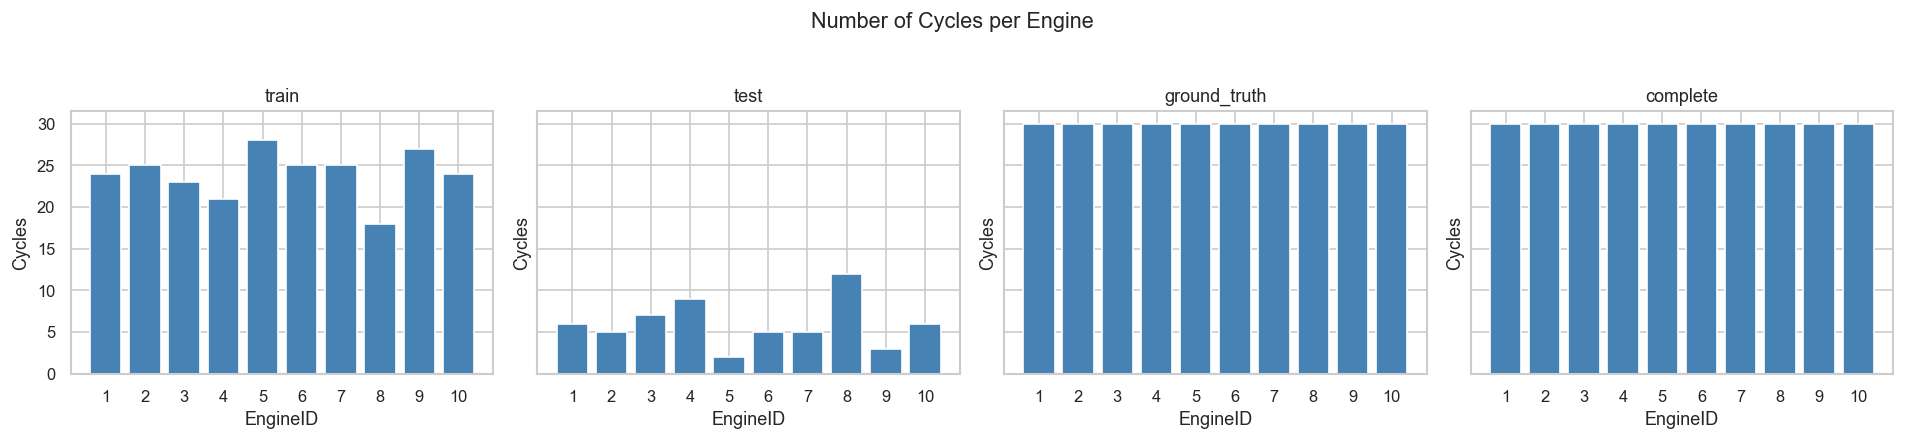

In [62]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, (name, df) in zip(axes, [("train", train), ("test", test), ("ground_truth", gt), ("complete", complete)]):
    cycles = df.groupby("EngineID")["Cycle"].count()
    ax.bar(cycles.index.astype(str), cycles.values, color="steelblue", edgecolor="white")
    ax.set_title(name)
    ax.set_xlabel("EngineID")
    ax.set_ylabel("Cycles")

fig.suptitle("Number of Cycles per Engine", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

---
## 9. Descriptive Statistics

Summary statistics (count, mean, std, min, quartiles, max) for numerical features.

In [63]:
sep = "=" * 70
for name, df in [("train", train), ("test", test), ("ground_truth", gt), ("complete", complete)]:
    print()
    print(sep)
    print("{} - describe".format(name.upper()))
    print(sep)
    display(df.describe().T.style.format("{:.4f}"))


TRAIN - describe


,count,mean,std,min,25%,50%,75%,max
EngineID,240.0000,5.4958,2.8797,1.0000,3.0000,5.0000,8.0000,10.0000
Cycle,240.0000,15.4125,8.6431,1.0000,8.0000,15.0000,23.0000,30.0000
Altitude_m,240.0000,5932.4822,3410.6159,17.7935,2825.7043,6182.0116,8543.2668,12053.3111
Mach,240.0000,0.4494,0.2584,0.0029,0.2321,0.4598,0.6722,0.8962
Tamb_K,240.0000,249.6956,22.3901,208.1710,232.8436,246.8529,269.9922,294.5175
Pamb_Pa,240.0000,51911.1296,23766.7131,19143.7318,32859.3372,46528.9104,71644.5540,102258.8421
RPM_rev_min,240.0000,55653.4349,14773.6179,30120.1307,42700.3990,55928.1860,69536.3172,80941.6381
FuelFlow_kg_s,240.0000,1.0675,0.5451,0.2005,0.5883,1.0304,1.5260,1.9978
P2_Pa,240.0000,231380.3887,163124.7179,23345.1863,115111.3289,180187.9691,298065.4311,712511.0480
T2_K,240.0000,402.2217,79.4734,212.2102,350.4577,404.5692,455.8821,598.6564



TEST - describe


,count,mean,std,min,25%,50%,75%,max
EngineID,60.0000,5.5167,2.8906,1.0000,3.0000,6.0000,8.0000,10.0000
Cycle,60.0000,15.8500,8.8410,1.0000,8.7500,16.5000,24.0000,30.0000
Altitude_m,60.0000,5424.9738,3108.8401,324.2992,3174.0838,4838.3587,7322.1684,12051.1626
Mach,60.0000,0.4374,0.2573,0.0188,0.2315,0.4344,0.5840,0.9021
Tamb_K,60.0000,252.5221,20.2577,209.7886,238.2628,253.8784,267.4386,289.4364
Pamb_Pa,60.0000,54604.9820,20988.5706,19864.0947,39367.2510,54761.8288,69113.4990,98172.4135
RPM_rev_min,60.0000,51657.3473,14397.9984,30498.7002,39819.5431,49484.9466,63484.1609,79747.3122
FuelFlow_kg_s,60.0000,1.0643,0.5337,0.2139,0.6437,0.9196,1.5198,1.9828
P2_Pa,60.0000,212040.2254,147429.7225,28925.2399,106301.8739,167038.3831,289157.6494,696979.7378
T2_K,60.0000,385.6374,78.2737,223.0843,333.2085,380.4274,444.9242,550.8859



GROUND_TRUTH - describe


,count,mean,std,min,25%,50%,75%,max
EngineID,300.0000,5.5000,2.8771,1.0000,3.0000,5.5000,8.0000,10.0000
Cycle,300.0000,15.5000,8.6699,1.0000,8.0000,15.5000,23.0000,30.0000
CompressorHealth,300.0000,0.8946,0.0731,0.7208,0.8378,0.9029,0.9587,0.9980
CombustorHealth,300.0000,0.9638,0.0268,0.8882,0.9450,0.9686,0.9863,0.9995
TurbineHealth,300.0000,0.9287,0.0516,0.7894,0.8939,0.9365,0.9725,0.9987
OverallHealth,300.0000,0.9256,0.0511,0.8009,0.8847,0.9319,0.9707,0.9986
Thrust_N,300.0000,46855.6652,17196.8955,13325.0840,34251.4543,45811.5271,60116.9258,88729.3208
TSFC_g_N_s,300.0000,0.0218,0.0064,0.0099,0.0164,0.0214,0.0261,0.0381



COMPLETE - describe


,count,mean,std,min,25%,50%,75%,max
EngineID,300.0000,5.5000,2.8771,1.0000,3.0000,5.5000,8.0000,10.0000
Cycle,300.0000,15.5000,8.6699,1.0000,8.0000,15.5000,23.0000,30.0000
Altitude_m,300.0000,5830.9805,3353.5841,17.7935,2968.4368,6001.2656,8472.6849,12053.3111
Mach,300.0000,0.4470,0.2577,0.0029,0.2321,0.4467,0.6660,0.9021
Tamb_K,300.0000,250.2609,21.9768,208.1710,233.7405,248.7719,269.1972,294.5175
Pamb_Pa,300.0000,52449.9001,23229.2453,19143.7318,33452.0007,47142.1411,70475.6674,102258.8421
RPM_rev_min,300.0000,54854.2174,14762.4927,30120.1307,41995.7301,54918.5612,68012.9800,80941.6381
FuelFlow_kg_s,300.0000,1.0669,0.5419,0.2005,0.6070,1.0252,1.5260,1.9978
P2_Pa,300.0000,227512.3560,160059.1641,23345.1863,112256.7393,176959.2807,295973.8171,712511.0480
T2_K,300.0000,398.9049,79.3833,212.2102,346.0214,401.0750,452.2280,598.6564


---
## 10. Distribution Plots for Numerical Features

Histograms (with KDE overlay) for every numeric column in the **complete** dataset.
This helps us understand the shape, range, and potential outliers of each variable.

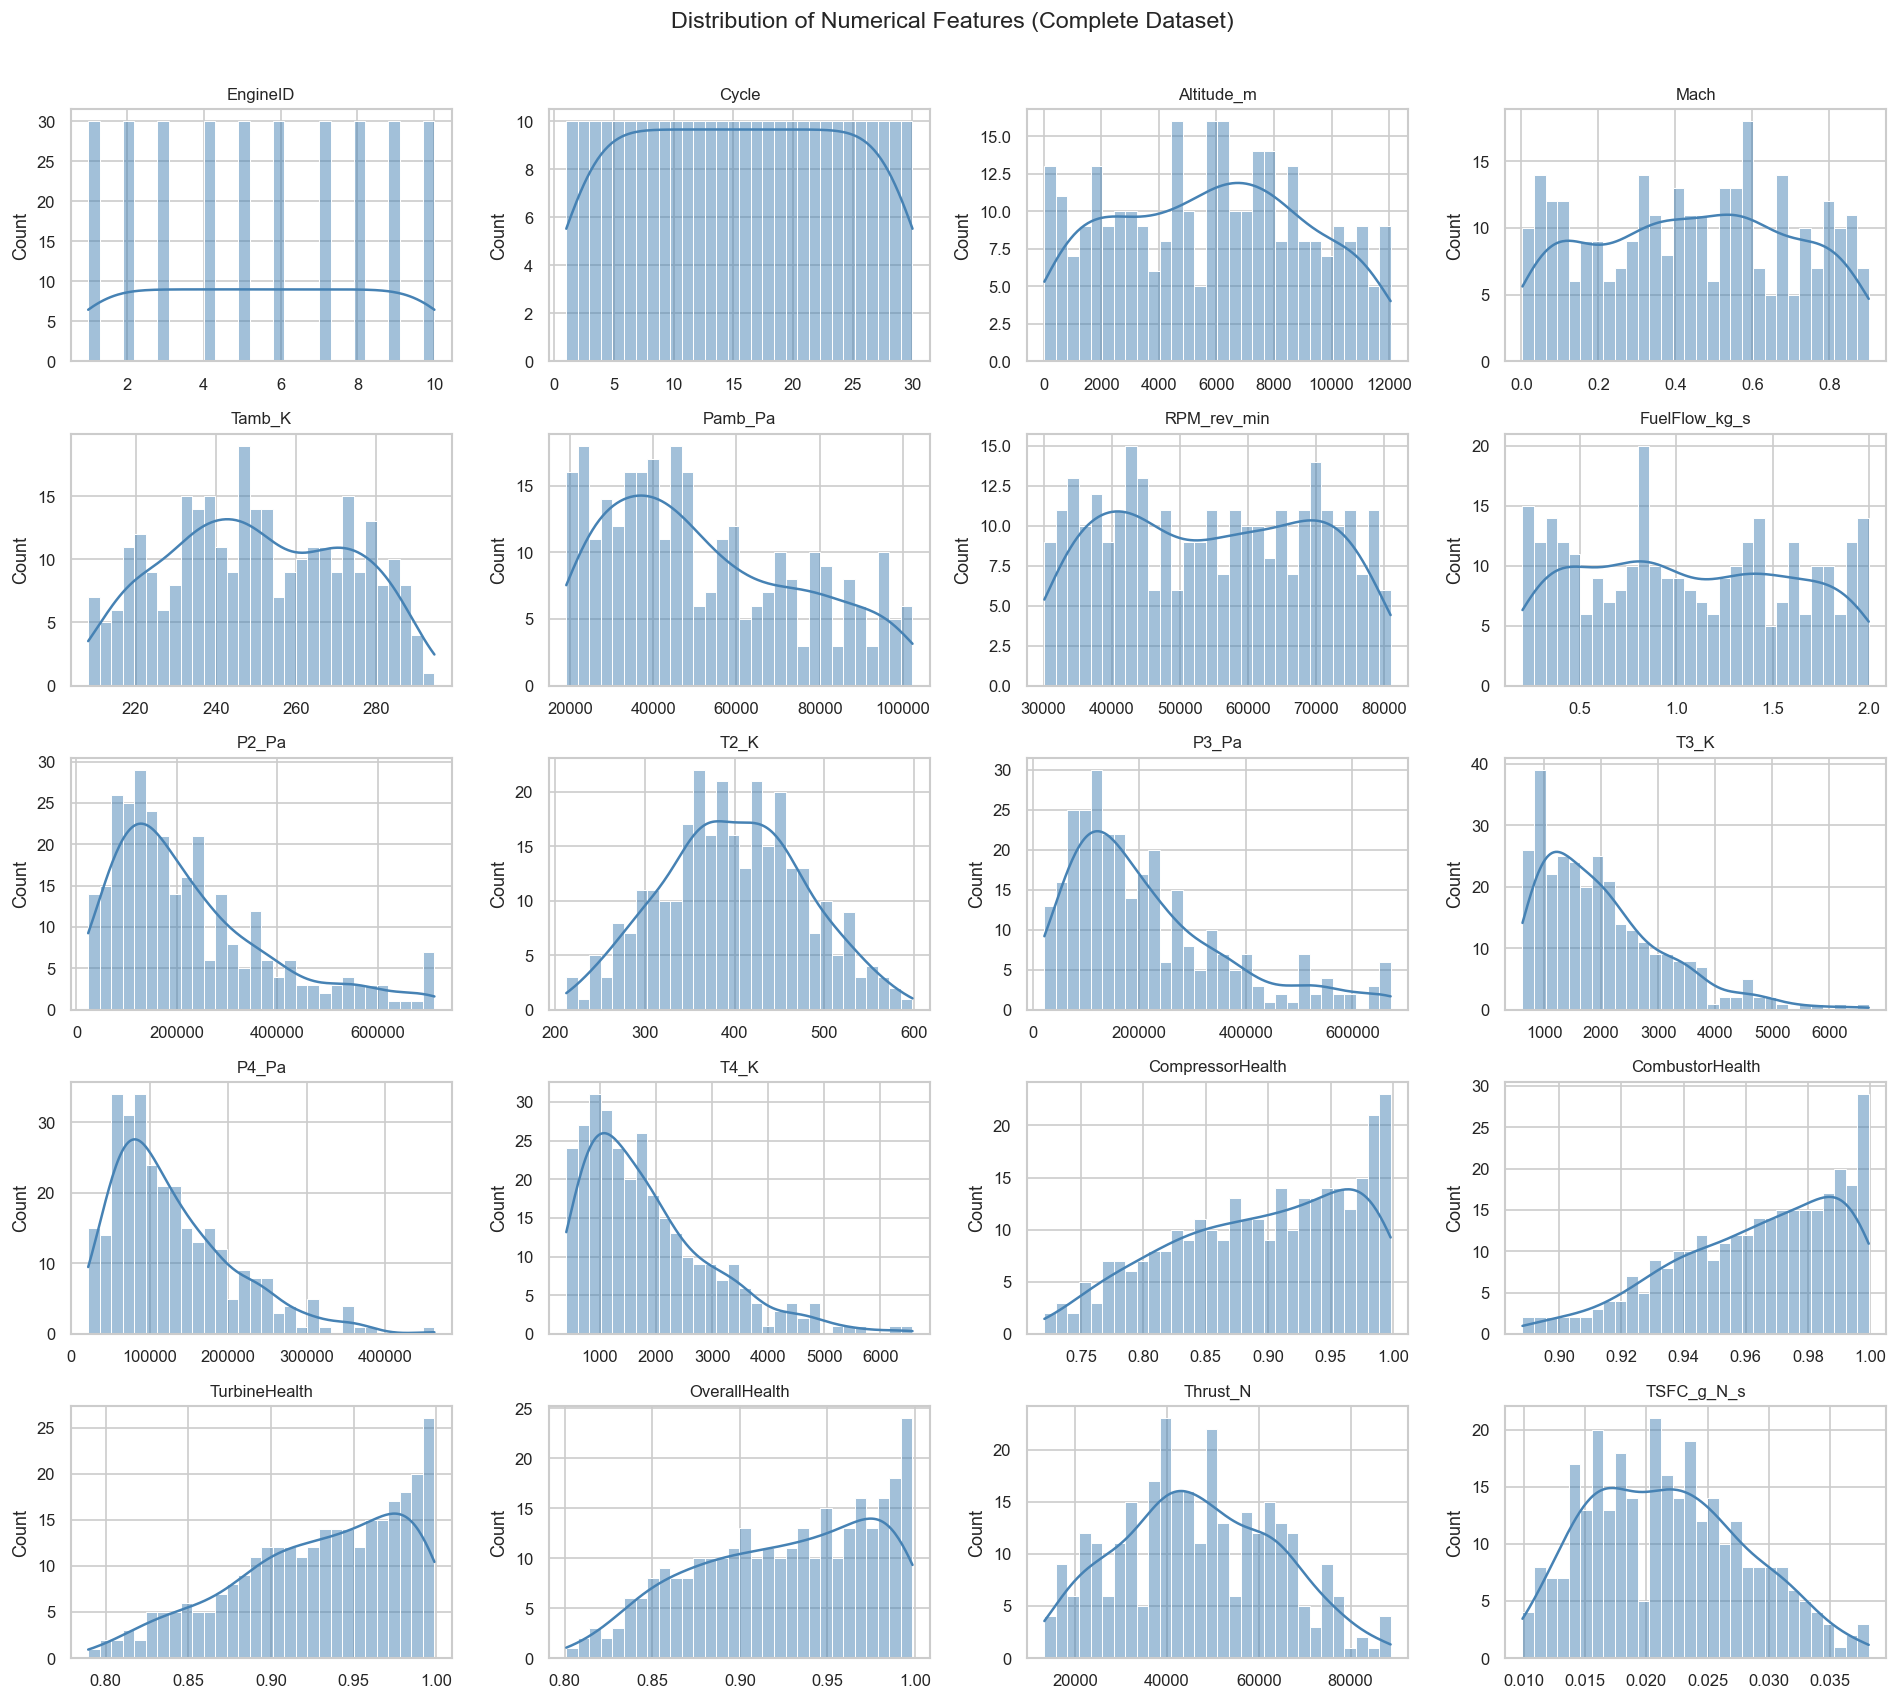

In [64]:
num_cols = complete.select_dtypes(include=np.number).columns.tolist()
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2.8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(complete[col], kde=True, bins=30, color="steelblue", ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution of Numerical Features (Complete Dataset)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 11. Correlation Heatmap

A heatmap of Pearson correlations for the **complete** dataset provides insight into linear relationships
between sensor measurements and target variables.

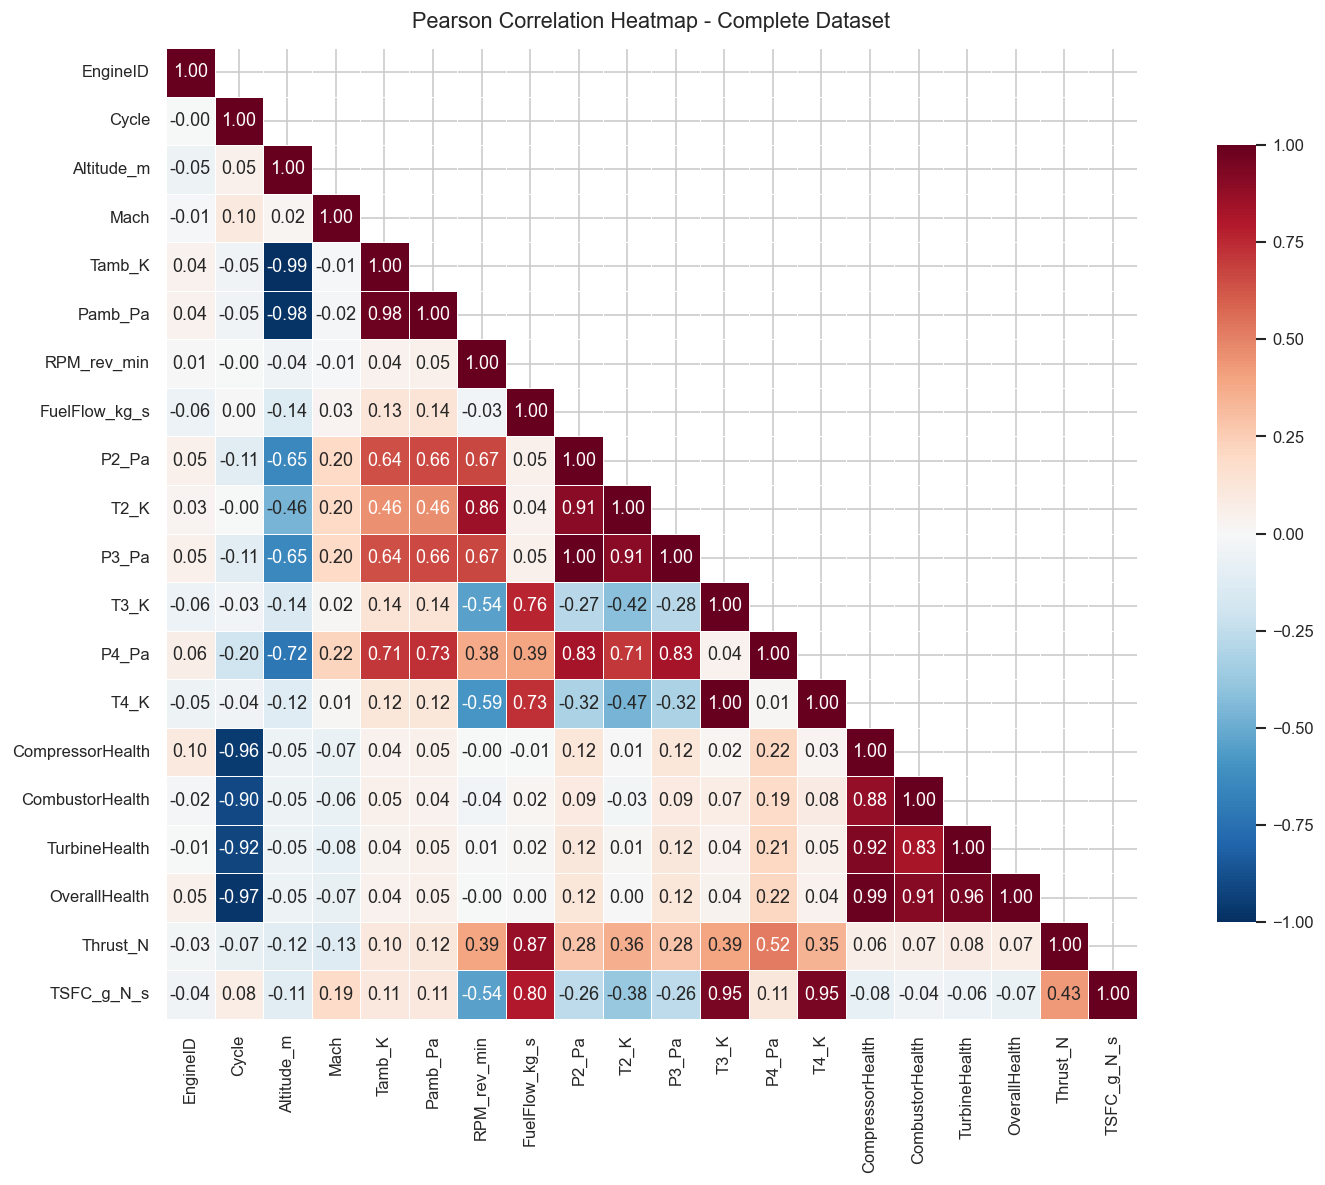

In [65]:
corr = complete.select_dtypes(include=np.number).corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson Correlation Heatmap - Complete Dataset", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## 12. Target Variable Analysis

The **ground truth** contains health indicators and performance targets:
- CompressorHealth, CombustorHealth, TurbineHealth, OverallHealth
- Thrust_N, TSFC_g_N_s

We examine their distributions and check for class imbalance or skewed ranges.

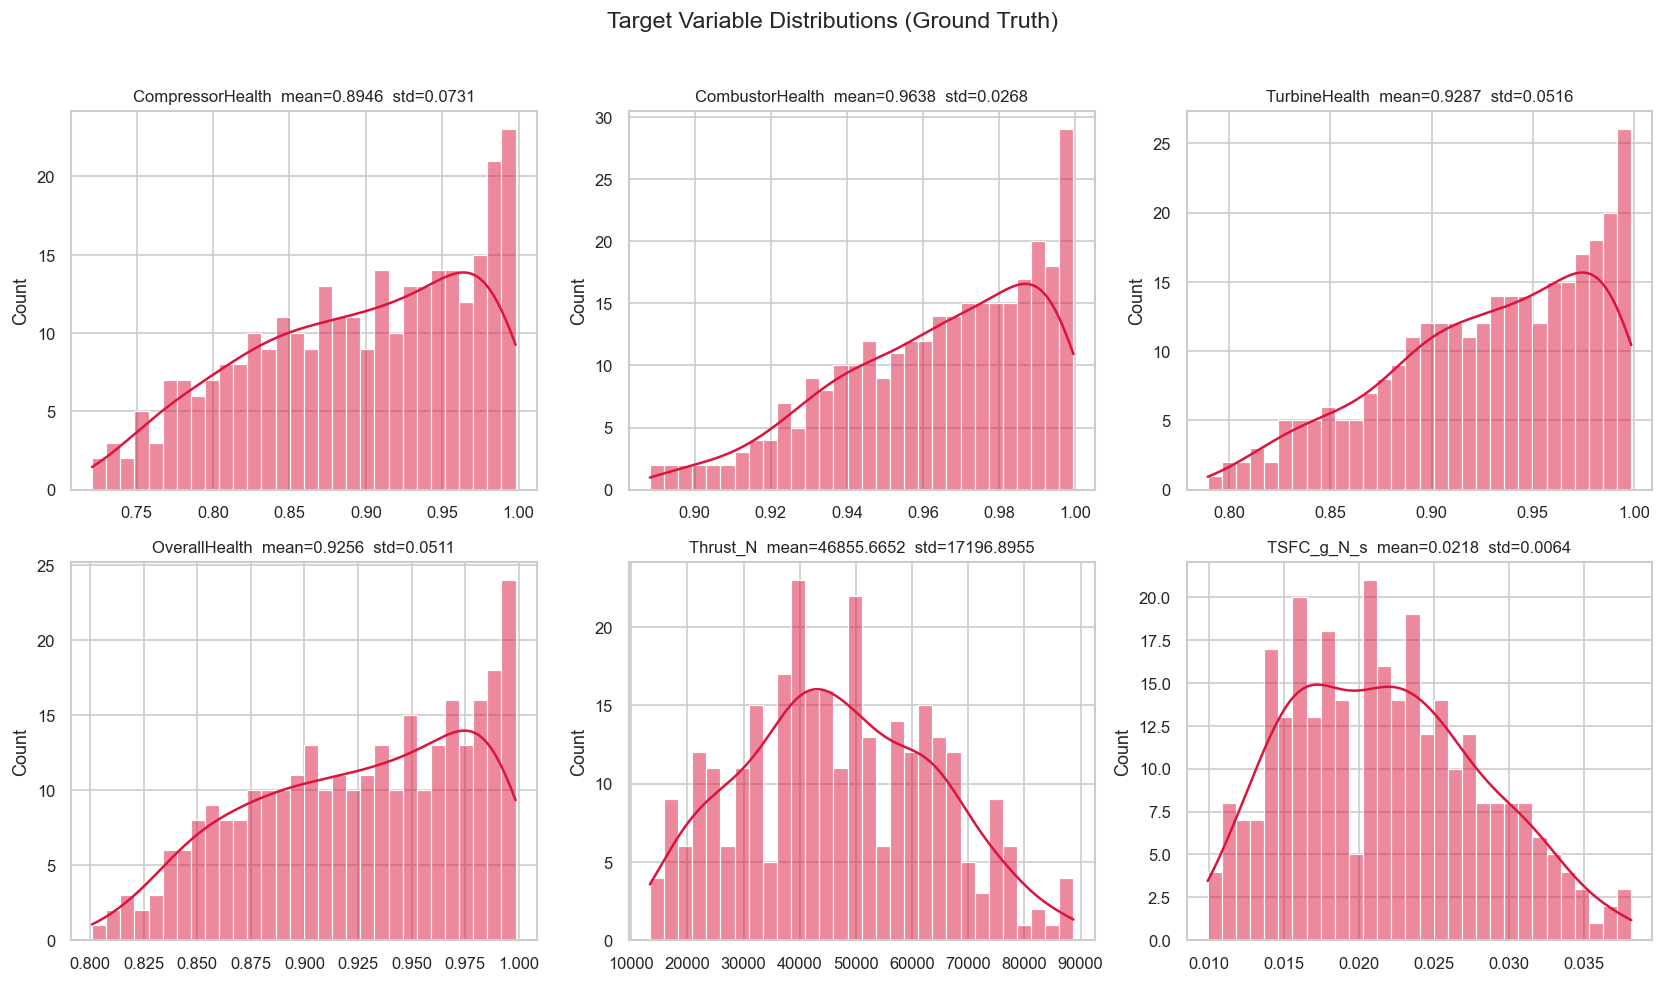

In [66]:
target_cols = ["CompressorHealth", "CombustorHealth", "TurbineHealth",
               "OverallHealth", "Thrust_N", "TSFC_g_N_s"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    sns.histplot(gt[col], kde=True, bins=30, color="crimson", ax=axes[i])
    title = "{}  mean={:.4f}  std={:.4f}".format(col, gt[col].mean(), gt[col].std())
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel("")

fig.suptitle("Target Variable Distributions (Ground Truth)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [67]:
target_stats = gt[target_cols].describe().T
target_stats["skew"] = gt[target_cols].skew().values
target_stats["kurtosis"] = gt[target_cols].kurtosis().values
display(target_stats.style.format("{:.4f}"))

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
CompressorHealth,300.0000,0.8946,0.0731,0.7208,0.8378,0.9029,0.9587,0.9980,-0.3889,-0.9046
CombustorHealth,300.0000,0.9638,0.0268,0.8882,0.9450,0.9686,0.9863,0.9995,-0.6478,-0.3565
TurbineHealth,300.0000,0.9287,0.0516,0.7894,0.8939,0.9365,0.9725,0.9987,-0.5723,-0.5581
OverallHealth,300.0000,0.9256,0.0511,0.8009,0.8847,0.9319,0.9707,0.9986,-0.3505,-0.9595
Thrust_N,300.0000,46855.6652,17196.8955,13325.0840,34251.4543,45811.5271,60116.9258,88729.3208,0.1492,-0.6413
TSFC_g_N_s,300.0000,0.0218,0.0064,0.0099,0.0164,0.0214,0.0261,0.0381,0.3268,-0.6245


---
## 13. Split Integrity - train + test vs. complete dataset

The feature columns of turbojet_complete_dataset.csv should be exactly the union of train.csv and test.csv,
with no overlap and no missing rows.

Columns in the feature set:
EngineID, Cycle, Altitude_m, Mach, Tamb_K, Pamb_Pa, RPM_rev_min, FuelFlow_kg_s, P2_Pa, T2_K, P3_Pa, T3_K, P4_Pa, T4_K

In [68]:
feature_cols = train.columns.tolist()

combined = pd.concat([train, test], axis=0, ignore_index=True)

complete_features = complete[feature_cols].reset_index(drop=True)

match = combined.equals(complete_features)

print("Feature columns in train:       {} rows".format(len(train)))
print("Feature columns in test:        {} rows".format(len(test)))
print("Combined (train + test):        {} rows".format(len(combined)))
print("Complete dataset features:      {} rows".format(len(complete_features)))
print()
print("train + test == complete features: {}".format(match))

if not match:
    diff = pd.concat([combined, complete_features]).drop_duplicates(keep=False)
    print("Rows that differ: {}".format(len(diff)))

Feature columns in train:       240 rows
Feature columns in test:        60 rows
Combined (train + test):        300 rows
Complete dataset features:      300 rows

train + test == complete features: False
Rows that differ: 0


---
## 14. Ground Truth Alignment

Verify that ground_truth.csv aligns with the complete dataset on (EngineID, Cycle).
Every row in the complete dataset should have a matching target row in ground truth, and vice versa.

In [69]:
gt_key = gt[["EngineID", "Cycle"]].reset_index(drop=True)
complete_key = complete[["EngineID", "Cycle"]].reset_index(drop=True)

keys_match = gt_key.equals(complete_key)

print("Ground truth rows:               {}".format(len(gt)))
print("Complete dataset rows:           {}".format(len(complete)))
print()
print("(EngineID, Cycle) keys match:    {}".format(keys_match))

if not keys_match:
    gt_set = set(zip(gt_key["EngineID"], gt_key["Cycle"]))
    comp_set = set(zip(complete_key["EngineID"], complete_key["Cycle"]))
    only_gt = gt_set - comp_set
    only_comp = comp_set - gt_set
    print("Keys only in ground_truth:  {}".format(len(only_gt)))
    print("Keys only in complete:     {}".format(len(only_comp)))
else:
    merged = complete.merge(gt, on=["EngineID", "Cycle"], how="left", suffixes=("_feat", ""))
    for col in target_cols:
        mismatches = merged[col].isna().sum()
        print("{:<25} missing after merge: {}".format(col, mismatches))
    print()
    print("Ground truth aligns perfectly with the complete dataset.")

Ground truth rows:               300
Complete dataset rows:           300

(EngineID, Cycle) keys match:    True
CompressorHealth          missing after merge: 0
CombustorHealth           missing after merge: 0
TurbineHealth             missing after merge: 0
OverallHealth             missing after merge: 0
Thrust_N                  missing after merge: 0
TSFC_g_N_s                missing after merge: 0

Ground truth aligns perfectly with the complete dataset.


---
## Summary

- train.csv contains feature data for a subset of engines/cycles.
- test.csv contains feature data for the remaining engines/cycles.
- ground_truth.csv provides the health and performance targets for all rows.
- turbojet_complete_dataset.csv is the concatenation of features + targets.

The data is clean (no missing values, no duplicates), and the splits are consistent.
Next steps: feature engineering, model building, and evaluation.